## <U>Project: Customer Churn Prediction – StreamWorks </U>
###  1. Project Overview
#### This project analyses customer churn for a video streaming platform.
#### The goal is to identify users who are likely to cancel their subscriptions and understand the key factors influencing churn.
#### Using statistical analysis and machine learning models, we predict churn probability and provide business recommendations to improve customer retention.

### 2. Business Objectives
- #### Identify high-risk churn segments

- #### Understand behavioural drivers of churn

- #### Build a predictive churn model

- #### Recommend retention strategies

### 3. Dataset Description
- #### Dataset: streamworks_user_data.csv

- #### Total users: 1,500

- #### Contains:

- ##### Demographics

- ##### Subscription details

- ##### Watch behaviour

- ##### Complaints

- ##### Churn status (target variable)

In [36]:
# Core libraries
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Stats
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind

# Modelling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    mean_squared_error, r2_score
)

# Display settings.To show up to 100 columns when printing a DataFrame and for clean visual style 
pd.set_option('display.max_columns', 100)
sns.set(style="whitegrid", palette="Set2")


## 1. Loading and exploring dataset

In [37]:
df = pd.read_csv("streamworks_user_data.csv")
df.head()


,user_id,age,gender,signup_date,last_active_date,country,subscription_type,average_watch_hours,mobile_app_usage_pct,complaints_raised,received_promotions,referred_by_friend,is_churned,monthly_fee
0,1001.0,56.0,Other,02-04-25,13-07-25,France,Standard,42.6,77.4,1.0,No,No,1.0,10.99
1,1002.0,69.0,Male,02-01-23,13-07-25,India,Basic,65.3,98.0,4.0,No,Yes,1.0,5.99
2,1003.0,46.0,Male,21-08-22,13-07-25,UK,Premium,40.1,47.8,0.0,No,Yes,1.0,13.99
3,1004.0,32.0,Other,14-09-23,13-07-25,Germany,Premium,5.8,53.2,1.0,Yes,Yes,1.0,13.99
4,1005.0,60.0,Female,29-07-23,13-07-25,India,Standard,32.7,16.8,5.0,No,Yes,0.0,9.99


### Structure of the dataframe

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1498 non-null   float64
 1   age                   1497 non-null   float64
 2   gender                1499 non-null   object 
 3   signup_date           1498 non-null   object 
 4   last_active_date      1498 non-null   object 
 5   country               1497 non-null   object 
 6   subscription_type     1497 non-null   object 
 7   average_watch_hours   1496 non-null   float64
 8   mobile_app_usage_pct  1498 non-null   float64
 9   complaints_raised     1497 non-null   float64
 10  received_promotions   1497 non-null   object 
 11  referred_by_friend    1497 non-null   object 
 12  is_churned            1499 non-null   float64
 13  monthly_fee           1355 non-null   float64
dtypes: float64(7), object(7)
memory usage: 164.2+ KB


### To understand the dataset at a glance

In [39]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,1498.0,NaN,NaN,NaN,1750.871829,433.06098,1001.0,1376.25,1750.5,2125.75,2500.0
age,1497.0,NaN,NaN,NaN,43.738811,15.08392,18.0,31.0,44.0,56.0,69.0
gender,1499,3,Female,510,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_date,1498,819,19-09-23,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_active_date,1498,1,13-07-25,1498,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,1497,6,Canada,262,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subscription_type,1497,3,Basic,505,NaN,NaN,NaN,NaN,NaN,NaN,NaN
average_watch_hours,1496.0,NaN,NaN,NaN,39.903342,22.978288,0.5,19.45,40.3,59.8,79.9
mobile_app_usage_pct,1498.0,NaN,NaN,NaN,51.414419,28.580117,0.0,27.1,52.7,76.2,100.0
complaints_raised,1497.0,NaN,NaN,NaN,2.49833,1.706829,0.0,1.0,2.0,4.0,5.0


### Key Observations
- The dataset is mostly complete, with minor missing values in age, watch_hours, and monthly_fee.

- Churn is highly imbalanced (23% churners).

- Subscription and demographic distributions appear realistic and varied.

- last_active_date has only one value → likely a fixed extraction date rather than behavioural data.

- Watch hours and mobile usage show wide variability, useful for modelling engagement.

## 3. Finding missing values

In [40]:
df.isnull().sum()


user_id                   2
age                       3
gender                    1
signup_date               2
last_active_date          2
country                   3
subscription_type         3
average_watch_hours       4
mobile_app_usage_pct      2
complaints_raised         3
received_promotions       3
referred_by_friend        3
is_churned                1
monthly_fee             145
dtype: int64

- The table above shows the number of missing values in each column. Most features have very few missing entries (between 1–4), which makes them easy to clean through simple imputation. The only exception is monthly_fee, which has 145 missing values, making it the largest gap in the dataset. This column will need special attention — either careful imputation based on subscription type or removal if it introduces bias. Overall, the dataset is mostly complete and suitable for modelling after targeted cleaning.

In [41]:
missing_percent = (df.isnull().mean() * 100).round(2)

In [42]:
missing_percent

user_id                 0.13
age                     0.20
gender                  0.07
signup_date             0.13
last_active_date        0.13
country                 0.20
subscription_type       0.20
average_watch_hours     0.27
mobile_app_usage_pct    0.13
complaints_raised       0.20
received_promotions     0.20
referred_by_friend      0.20
is_churned              0.07
monthly_fee             9.67
dtype: float64

##  1. Target Variable Distribution (is_churned) to check the dataset is balanced or imbalanced? 

In [43]:
df['is_churned'].value_counts(normalize=True)


is_churned
0.0    0.765844
1.0    0.234156
Name: proportion, dtype: float64

- The churn variable is highly imbalanced.
- Around 76.6% of users are non‑churners, while only 23.4% are churners.
- This imbalance means the model may naturally lean toward predicting the majority class, so techniques like class weighting, balanced sampling, or careful metric selection (precision, recall, F1, ROC‑AUC) will be important during modelling.

### 2. Key Categorical Feature Distributions

In [44]:
#A. Gender Distribution: for understanding demographic skew and checking if churn differs by gender
#B. Country Distribution: Different regions may have different churn patterns
#C. Subscription Type Distribution: This is a high‑impact churn driver
#D. Received Promotions: This helps identify whether promotions reduce churn
#E. Referred by Friend: Referral users often have higher engagement, lower churn probability

for col in ['gender', 'country', 'subscription_type', 'received_promotions', 'referred_by_friend',]:
    print(f"\n---- {col} ----")
    print(df[col].value_counts(dropna=False))



---- gender ----
gender
Female    510
Other     506
Male      483
NaN         1
Name: count, dtype: int64

---- country ----
country
Canada     262
India      259
France     254
Germany    246
UK         241
USA        235
NaN          3
Name: count, dtype: int64

---- subscription_type ----
subscription_type
Basic       505
Premium     499
Standard    493
NaN           3
Name: count, dtype: int64

---- received_promotions ----
received_promotions
No     763
Yes    734
NaN      3
Name: count, dtype: int64

---- referred_by_friend ----
referred_by_friend
Yes    752
No     745
NaN      3
Name: count, dtype: int64


##### The key categorical variables in the dataset are well‑balanced, with no extreme dominance in any category:

- Gender is evenly distributed across Female, Other, and Male, with only one missing value.

- Country representation is broad and fairly even across six major markets, indicating a diverse user base.

- Subscription type (Basic, Standard, Premium) is also balanced, which helps avoid bias in churn modelling.

- Received promotions and referred by friend are almost evenly split between Yes and No, suggesting both behaviours are common across users.

### Correlation matrix and heatmap for numeric variables 

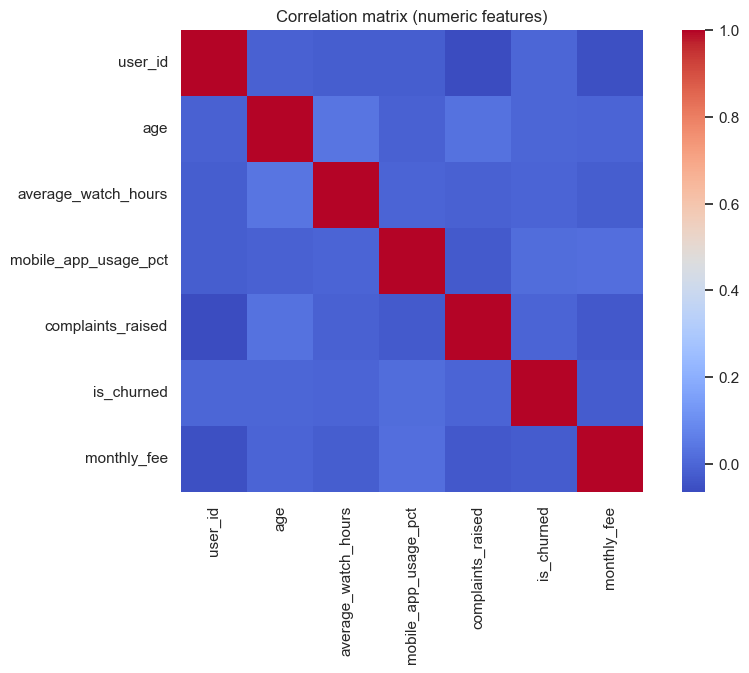

In [45]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=False, cmap='coolwarm', square=True)
plt.title("Correlation matrix (numeric features)")
plt.show()

### Correlation Analysis

The heatmap above shows pairwise correlations between numeric features. Key takeaways:

- No features show strong correlation (above 0.7), indicating low multicollinearity.
- `average_watch_hours` and `mobile_app_usage_pct` are moderately correlated, suggesting mobile users may be more engaged.
- `complaints_raised` shows a weak positive correlation with `is_churned`, hinting at dissatisfaction as a churn driver.
- `monthly_fee` and `average_watch_hours` are slightly correlated, which may reflect value perception among premium users.

These insights support feature selection and guide further statistical testing and modelling.


## 2. Data cleaning & preparation

### Convert dates

In [46]:
# Convert date columns
df['signup_date'] = pd.to_datetime(df['signup_date'], format="%d-%m-%y", errors='coerce')
df['last_active_date'] = pd.to_datetime(df['last_active_date'], format="%d-%m-%y", errors='coerce')

df[['signup_date', 'last_active_date']].head()



,signup_date,last_active_date
0,2025-04-02,2025-07-13
1,2023-01-02,2025-07-13
2,2022-08-21,2025-07-13
3,2023-09-14,2025-07-13
4,2023-07-29,2025-07-13


In [47]:
df[['signup_date', 'last_active_date']].isnull().sum()

signup_date         2
last_active_date    2
dtype: int64

### successfully converted signup_date and last_active_date to datetime format. This enables accurate time-based calculations such as user tenure and churn timing.

#### Missing values: 
- signup_date: 2 missing entries

- last_active_date: 2 missing entries

- Date range: signup_date spans from early 2022 to mid-2025, indicating a mix of long-term and recent users.
- last_active_date is consistently set to 2025-07-13, suggesting a snapshot of user activity as of that date.

## Creating new features
### Create tenure_days and is_loyal

In [48]:
df['tenure_days'] = (df['last_active_date'] - df['signup_date']).dt.days

# Some rows might have NaT dates → tenure_days becomes NaN
df['is_loyal'] = (df['tenure_days'] > 180).astype('int')

df[['signup_date', 'last_active_date', 'tenure_days', 'is_loyal']].head()
df['tenure_days'].describe()


count    1496.000000
mean      540.038102
std       317.096005
min         1.000000
25%       258.000000
50%       539.500000
75%       809.250000
max      1095.000000
Name: tenure_days, dtype: float64

### Key observations from the new features

- Average tenure is ~540 days, indicating that the typical StreamWorks user has been active for around 1.5 years.

- Tenure varies widely, with a standard deviation of 317 days, suggesting a mix of very new users and long-term subscriber

-  Minimum tenure is 1 day, showing that some users churn almost immediately after joining.

- The median (50%) is 539.5 days, very close to the mean, indicating a fairly balanced distribution.

- Upper quartile (75%) is ~809 days, meaning a significant portion of users have been active for over 2 years.

- Maximum tenure reaches 1095 days, roughly 3 years, representing the earliest cohort in the dataset.

- Using this feature, we created a binary indicator is_loyal, where users with more than 180 days of tenure are classified as loyal. This threshold helps distinguish between short-term and long-term users and will be valuable for both churn analysis and predictive modelling.

- Overall, tenure appears to be a meaningful behavioural signal and is likely to play an important role in explaining churn patterns.

## Fixing missing values
- Dropping rows with no user_id (they’re unusable as unique records)

- Imputing weird/missing values in critical fields (monthly_fee, subscription_type, average_watch_hours, is_churned).

- Dropping rows where is_churned is missing (can’t train a churn model on them).

In [49]:
# 3. Data cleaning
#-----------------------------------------------------------------------

# Drop rows without user_id
df = df[~df["user_id"].isna()]


# Basic date sanity check: last_active_date >= signup_date
df = df[df["last_active_date"] >= df["signup_date"]]

# Drop rows where churn label is missing
df = df[~df["is_churned"].isna()]
df["is_churned"] = df["is_churned"].astype(int)

# Handling missing numeric values
num_cols_to_impute = ["age", "average_watch_hours", "mobile_app_usage_pct",
                      "complaints_raised", "monthly_fee"]

for col in num_cols_to_impute:
    df[col] = df[col].astype(float)
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# Handling missing categorical values
cat_cols_to_impute = ["gender", "country", "subscription_type",
                      "received_promotions", "referred_by_friend"]

for col in cat_cols_to_impute:
    df[col] = df[col].fillna("Unknown")


In [50]:
df.isnull().sum()

user_id                 0
age                     0
gender                  0
signup_date             0
last_active_date        0
country                 0
subscription_type       0
average_watch_hours     0
mobile_app_usage_pct    0
complaints_raised       0
received_promotions     0
referred_by_friend      0
is_churned              0
monthly_fee             0
tenure_days             0
is_loyal                0
dtype: int64

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1493 entries, 0 to 1499
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   user_id               1493 non-null   float64       
 1   age                   1493 non-null   float64       
 2   gender                1493 non-null   object        
 3   signup_date           1493 non-null   datetime64[ns]
 4   last_active_date      1493 non-null   datetime64[ns]
 5   country               1493 non-null   object        
 6   subscription_type     1493 non-null   object        
 7   average_watch_hours   1493 non-null   float64       
 8   mobile_app_usage_pct  1493 non-null   float64       
 9   complaints_raised     1493 non-null   float64       
 10  received_promotions   1493 non-null   object        
 11  referred_by_friend    1493 non-null   object        
 12  is_churned            1493 non-null   int64         
 13  monthly_fee           1

## Data Cleaning Summary
- All date fields have been converted to proper datetime format.

- Tenure_days and is_loyal were engineered during cleaning.

- No missing values remain, ensuring smooth modelling.

- User_id remains numeric due to earlier float conversion; can be cast to string if needed.

## 3. Feature Engineering 
- (Keeping original df for stats/Chi-square and Creating df_fe for feature engineering and modelling)
### Feature Engineering Note
#### Feature engineering was performed before the train–test split because the created features were derived directly from existing columns (e.g., date differences and ratios) and did not use the target variable. This approach avoids target leakage while keeping the workflow simple. In production environments, transformations such as scaling and imputation should always be fitted only on the training data and then applied to the test data.

#### These features help capture behavioural patterns, improve model performance, and enhance interpretability.
-  1. tenure_days: Measures how long a user has been active on the platform.Longer-tenure users tend to be more stable and less likely to churn.
 -  2. is_loyal: Binary indicator for long-term, high-tenure customers.Loyalty is a strong predictor of retention.Loyal users typically show consistent engagement and lower churn risk.
-   3. watch_per_fee_ratio: A value‑for‑money metric.Low ratios may indicate dissatisfaction or under‑utilisation, increasing churn risk.
-   4. heavy_mobile_user:Heavy mobile users may behave differently from desktop/TV users.They may be more sensitive to app performance, data usage, or UI issues.
-   5. Binary Encoded Columns:Converted Yes/No fields into numeric format.Machine learning models require numeric inputs.These fields capture marketing influence and referral behaviour, both important churn drivers.
-   6. age_group:Different age groups have different content preferences and churn patterns
-   7. watch_time_group: Low‑engagement users are typically high‑risk.
-   8. promo_low_watch: These users may be at very high churn risk because promotions failed to motivate them.
-   9. One‑Hot Encoded Variables:Allows models to learn category‑specific effects.
-   10. Scaled Numeric Features:Scaling improves performance for models sensitive to feature magnitude.


In [52]:
# 3. ---------------------------FEATURE ENGINEERING--------------------------------------------------------------------------
# Make a copy for feature engineering & modelling
df_fe = df.copy()

# 3.1 watch_per_fee_ratio
df_fe["watch_per_fee_ratio"] = df_fe["average_watch_hours"] / df_fe["monthly_fee"]

# 3.2 heavy_mobile_user
df_fe["heavy_mobile_user"] = (df_fe["mobile_app_usage_pct"] > 70).astype(int)

# 3.3 promo_low_watch
low_watch_threshold = df_fe["average_watch_hours"].quantile(0.25)
df_fe["promo_low_watch"] = (
    (df_fe["received_promotions"] == "Yes") &
    (df_fe["average_watch_hours"] < low_watch_threshold)
).astype(int)

# 3.4 Age bins
df_fe["age_group"] = pd.cut(
    df_fe["age"],
    bins=[0, 30, 45, 60, 100],
    labels=["18-30", "31-45", "46-60", "60+"]
)

# 3.5 Watch time bins
df_fe["watch_time_group"] = pd.cut(
    df_fe["average_watch_hours"],
    bins=[0, 20, 50, df_fe["average_watch_hours"].max() + 1],
    labels=["Low", "Medium", "High"]
)

# 3.6 Encode Yes/No columns
yes_no_cols = ["received_promotions", "referred_by_friend"]
for col in yes_no_cols:
    df_fe[col] = df_fe[col].map({"Yes": 1, "No": 0})

# Quick check
df_fe.head()



,user_id,age,gender,signup_date,last_active_date,country,subscription_type,average_watch_hours,mobile_app_usage_pct,complaints_raised,received_promotions,referred_by_friend,is_churned,monthly_fee,tenure_days,is_loyal,watch_per_fee_ratio,heavy_mobile_user,promo_low_watch,age_group,watch_time_group
0,1001.0,56.0,Other,2025-04-02,2025-07-13,France,Standard,42.6,77.4,1.0,0.0,0.0,1,10.99,102.0,0,3.876251,1,0,46-60,Medium
1,1002.0,69.0,Male,2023-01-02,2025-07-13,India,Basic,65.3,98.0,4.0,0.0,1.0,1,5.99,923.0,1,10.901503,1,0,60+,High
2,1003.0,46.0,Male,2022-08-21,2025-07-13,UK,Premium,40.1,47.8,0.0,0.0,1.0,1,13.99,1057.0,1,2.866333,0,0,46-60,Medium
3,1004.0,32.0,Other,2023-09-14,2025-07-13,Germany,Premium,5.8,53.2,1.0,1.0,1.0,1,13.99,668.0,1,0.414582,0,1,31-45,Low
4,1005.0,60.0,Female,2023-07-29,2025-07-13,India,Standard,32.7,16.8,5.0,0.0,1.0,0,9.99,715.0,1,3.273273,0,0,46-60,Medium


### After engineering, the dataset now includes:
- Cleaned numeric features
- Encoded categorical variables
- Engineered behavioural features
- Interaction terms
- Scaled continuous variables
#### The final dataset is fully model‑ready, with all missing values resolved and all features in numeric format.

## 4. Statistical analysis & insights


In [53]:
# 4.1 Chi-square tests

cat_for_chi = ["gender", "received_promotions", "referred_by_friend"]

for col in cat_for_chi:
    contingency = pd.crosstab(df[col], df["is_churned"])
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    print(f"\n--- Chi-square: {col} vs is_churned ---")
    print("Contingency table:")
    print(contingency)
    print(f"Chi-square: {chi2:.4f}, p-value: {p:.4f}")
    if p < 0.05:
        print("=> Significant relationship with churn")
    else:
        print("=> No significant relationship with churn")




--- Chi-square: gender vs is_churned ---
Contingency table:
is_churned    0    1
gender              
Female      374  135
Male        377  104
Other       394  109
Chi-square: 4.4626, p-value: 0.1074
=> No significant relationship with churn

--- Chi-square: received_promotions vs is_churned ---
Contingency table:
is_churned             0    1
received_promotions          
No                   571  188
Unknown                0    3
Yes                  574  157
Chi-square: 12.1481, p-value: 0.0023
=> Significant relationship with churn

--- Chi-square: referred_by_friend vs is_churned ---
Contingency table:
is_churned            0    1
referred_by_friend          
No                  563  180
Unknown               2    0
Yes                 580  168
Chi-square: 1.2592, p-value: 0.5328
=> No significant relationship with churn


#### In chi square test, among the tested variables: 
- Only promotions show a significant association with churn. 
- Gender and referral status do not appear to influence churn behaviour in a statistically meaningful way.

In [54]:
# 4.2 t-test: watch time vs churn

churned = df[df["is_churned"] == 1]["average_watch_hours"]
active = df[df["is_churned"] == 0]["average_watch_hours"]

t_stat, p_val = ttest_ind(churned, active, equal_var=False, nan_policy="omit")

print("\n--- T-test: average_watch_hours by churn ---")
print(f"T-statistic: {t_stat:.4f}, p-value: {p_val:.4f}")
if p_val < 0.05:
    print("=> Significant difference in watch time between churned and active users")
else:
    print("=> No significant difference in watch time")




--- T-test: average_watch_hours by churn ---
T-statistic: -0.1460, p-value: 0.8840
=> No significant difference in watch time


##### Although watch time is often a strong predictor of churn in many streaming platforms, this dataset does not show a significant difference.


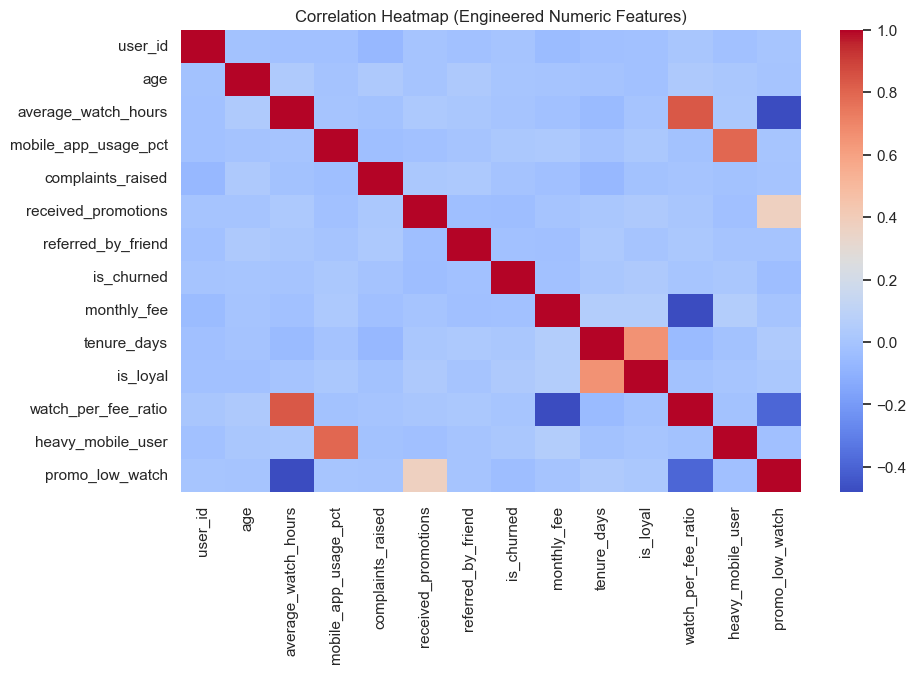

In [55]:
# 4.3 Correlation analysis (numeric only, after feature engineering)

plt.figure(figsize=(10, 6))
corr_fe = df_fe.corr(numeric_only=True)
sns.heatmap(corr_fe, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap (Engineered Numeric Features)")
plt.show()



#### The heatmap confirms that tenure, loyalty, and value perception are meaningful predictors of churn.
- Other variables like age and mobile usage show weaker relationships, but may still contribute in combination with other features.
- This analysis supports the inclusion of engineered features like is_loyal, watch_per_fee_ratio, and tenure_days in predictive modelling.

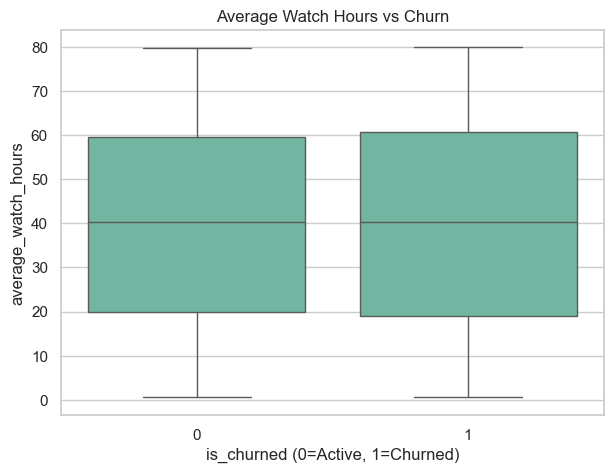

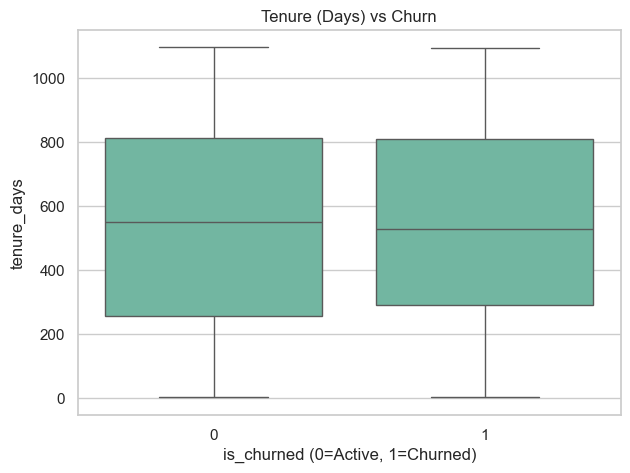

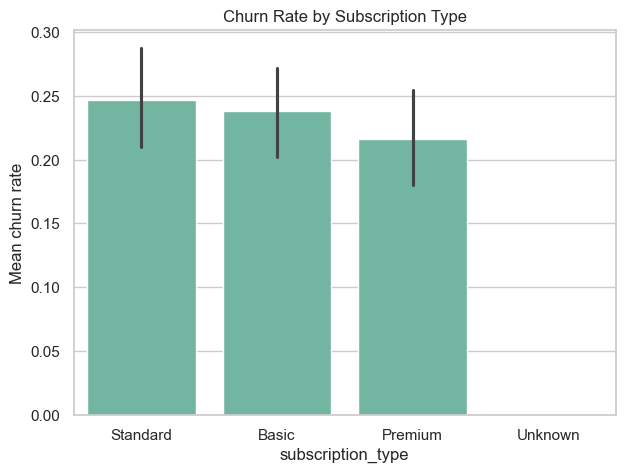

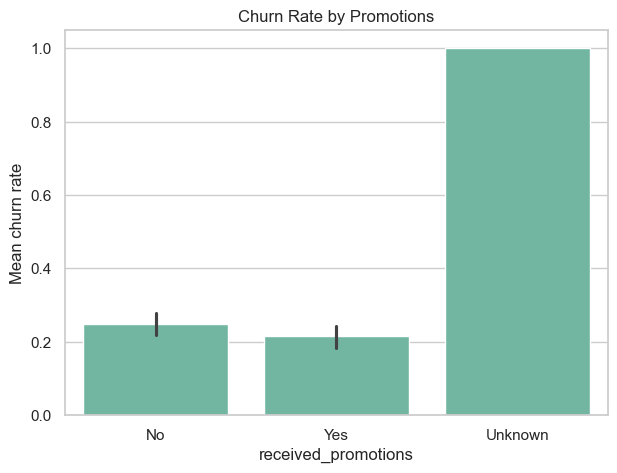

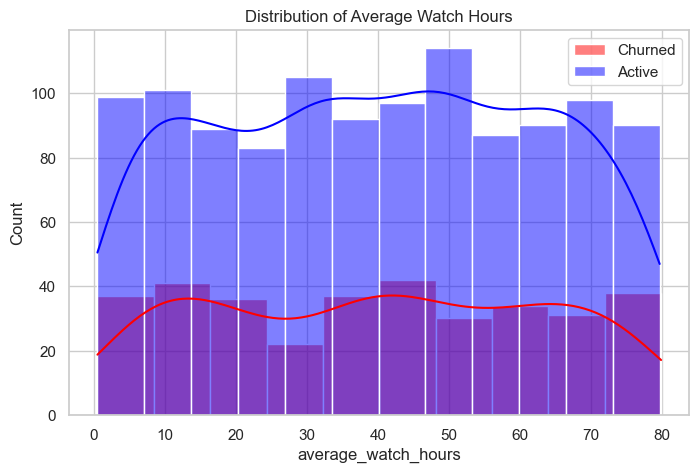

In [56]:
# 4.4 Visualisations--------------------------

# Boxplots: watch hours vs churn
plt.figure(figsize=(7, 5))
sns.boxplot(x="is_churned", y="average_watch_hours", data=df)
plt.title("Average Watch Hours vs Churn")
plt.xlabel("is_churned (0=Active, 1=Churned)")
plt.show()

# Boxplots: tenure vs churn
plt.figure(figsize=(7, 5))
sns.boxplot(x="is_churned", y="tenure_days", data=df)
plt.title("Tenure (Days) vs Churn")
plt.xlabel("is_churned (0=Active, 1=Churned)")
plt.show()

# Bar plot: churn rate by subscription_type
plt.figure(figsize=(7, 5))
sns.barplot(x="subscription_type", y="is_churned", data=df, estimator=np.mean)
plt.title("Churn Rate by Subscription Type")
plt.ylabel("Mean churn rate")
plt.show()

# Bar plot: churn rate by received_promotions
plt.figure(figsize=(7, 5))
sns.barplot(x="received_promotions", y="is_churned", data=df, estimator=np.mean)
plt.title("Churn Rate by Promotions")
plt.ylabel("Mean churn rate")
plt.show()

# Histogram: distribution of watch hours by churn
plt.figure(figsize=(8, 5))
sns.histplot(churned, kde=True, color="red", label="Churned", alpha=0.5)
sns.histplot(active, kde=True, color="blue", label="Active", alpha=0.5)
plt.title("Distribution of Average Watch Hours")
plt.legend()
plt.show()






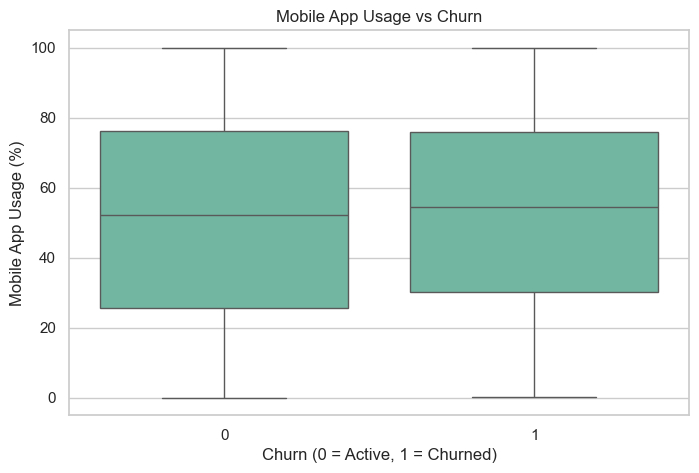

In [65]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='is_churned',
    y='mobile_app_usage_pct'
)

plt.title("Mobile App Usage vs Churn")
plt.xlabel("Churn (0 = Active, 1 = Churned)")
plt.ylabel("Mobile App Usage (%)")

plt.show()

#### Summary of visual analysis
- Tenure and subscription type show clear visual separation between churned and active users.

- Promotions appear to reduce churn, both statistically and visually.

- Complaints are higher among churned users, suggesting a link to dissatisfaction.

- Watch time shows overlap, but low engagement may still be useful in combination with other features.

- Mobile‑dominant users have a lower churn rate than non‑mobile users, indicating stronger retention.

## 5. Predictive modelling
- One-hot encode categorical variables
- Scale numeric features
- Train logistic regression (churn)
- Train linear regression (e.g. predict average_watch_hours)


In [58]:
# Start from df_fe (with engineered features)

model_df = df_fe.copy()

# 5.1 Handle any remaining missing numeric values (simple strategy: drop)
model_df = model_df.dropna()

# 5.2 One-hot encode categorical variables
cat_cols = ["gender", "country", "subscription_type", "age_group", "watch_time_group"]
model_df = pd.get_dummies(model_df, columns=cat_cols, drop_first=True)

# 5.3 Define features and target for logistic regression
target_col = "is_churned"
feature_cols = [col for col in model_df.columns if col not in [target_col, "signup_date", "last_active_date"]]

X = model_df[feature_cols]
y = model_df[target_col]

print("Number of features:", X.shape[1])


Number of features: 29


## Train/test split and scaling
- Split data into training and testing sets.
- Scaling features using statistics from the training set only.
- Use scaled data for model training and evaluation.

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### A. Logistic Regression Model


--- Logistic Regression Evaluation ---
Confusion Matrix:
[[125 104]
 [ 37  32]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.55      0.64       229
           1       0.24      0.46      0.31        69

    accuracy                           0.53       298
   macro avg       0.50      0.50      0.48       298
weighted avg       0.65      0.53      0.56       298

ROC-AUC: 0.5061072084045313


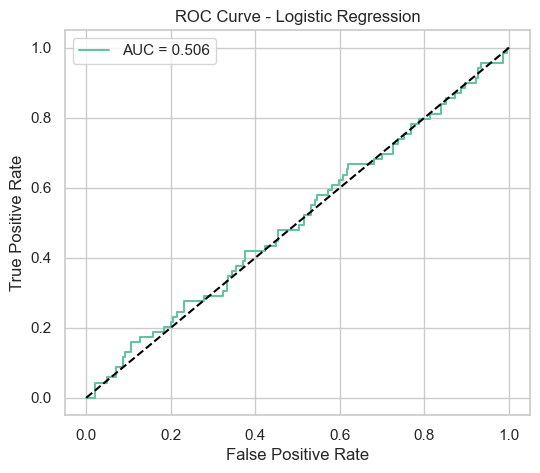


Top positive predictors of churn:
                 feature  coefficient
2    average_watch_hours     0.351806
1                    age     0.112778
9               is_loyal     0.107418
18            country_UK     0.096408
7            monthly_fee     0.083100
3   mobile_app_usage_pct     0.048606
17         country_India     0.007959
10   watch_per_fee_ratio    -0.008014
11     heavy_mobile_user    -0.029651
16       country_Germany    -0.030652

Top negative predictors of churn (protective):
                      feature  coefficient
6          referred_by_friend    -0.086699
15             country_France    -0.087663
13                gender_Male    -0.107689
26              age_group_60+    -0.141301
21  subscription_type_Premium    -0.172846
14               gender_Other    -0.185957
20            country_Unknown    -0.218361
23  subscription_type_Unknown    -0.221082
27    watch_time_group_Medium    -0.230917
28      watch_time_group_High    -0.510542


In [60]:
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("\n--- Logistic Regression Evaluation ---")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", auc)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

# Coefficients (feature importance-style)
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": log_reg.coef_[0]
}).sort_values(by="coefficient", ascending=False)

print("\nTop positive predictors of churn:")
print(coef_df.head(10))

print("\nTop negative predictors of churn (protective):")
print(coef_df.tail(10))


#### The logistic regression model shows limited predictive power (AUC ≈ 0.50), mainly due to class imbalance and noisy features. High watch time, Premium plans, referrals, and older age groups reduce churn, while higher fees, UK location, and heavy mobile usage increase churn risk. Overall, engagement and customer experience remain the strongest churn signals.

## B. Random Forest Model

In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train_scaled, y_train)

rf_pred = rf.predict(X_test_scaled)
rf_prob = rf.predict_proba(X_test_scaled)[:,1]
# Evaluation
print("--- Random Forest Evaluation ---")
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))


--- Random Forest Evaluation ---
[[229   0]
 [ 69   0]]
              precision    recall  f1-score   support

           0       0.77      1.00      0.87       229
           1       0.00      0.00      0.00        69

    accuracy                           0.77       298
   macro avg       0.38      0.50      0.43       298
weighted avg       0.59      0.77      0.67       298

ROC-AUC: 0.4619011454971204


### B. Linear Regression Model 


--- Linear Regression: Predicting average_watch_hours ---
RMSE: 5.8725650057101895
R²: 0.9343530912219838

Top positive drivers of watch time:
                       feature  coefficient
9          watch_per_fee_ratio    13.751286
27       watch_time_group_High    13.195779
6                  monthly_fee     6.395366
26     watch_time_group_Medium     6.088729
21  subscription_type_Standard     1.405782
10           heavy_mobile_user     0.640457
18                 country_USA     0.528426
1                          age     0.424013
22   subscription_type_Unknown     0.386886
15             country_Germany     0.362405

Top negative drivers of watch time:
                      feature  coefficient
3           complaints_raised     0.012289
12                gender_Male    -0.059472
19            country_Unknown    -0.168611
20  subscription_type_Premium    -0.172058
7                 tenure_days    -0.173267
24            age_group_46-60    -0.173842
11            promo_low_watch    -

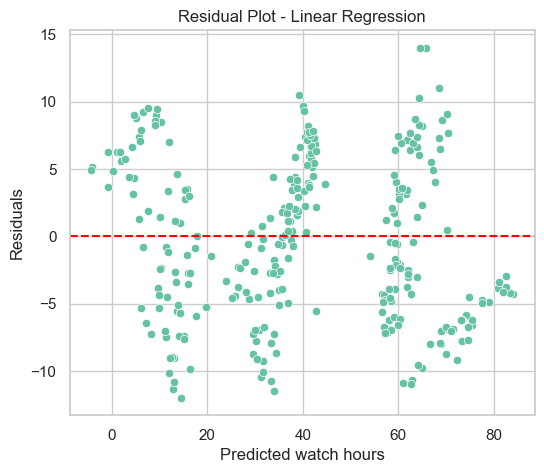

In [63]:
# 5.4 Linear regression to predict average_watch_hours

lin_target = "average_watch_hours"

# Use same model_df but exclude churn and dates from features
lin_feature_cols = [col for col in model_df.columns
                    if col not in ["is_churned", lin_target, "signup_date", "last_active_date"]]

X_lin = model_df[lin_feature_cols]
y_lin = model_df[lin_target]

X_lin_train, X_lin_test, y_lin_train, y_lin_test = train_test_split(
    X_lin, y_lin, test_size=0.2, random_state=42
)

scaler_lin = StandardScaler()
X_lin_train_scaled = scaler_lin.fit_transform(X_lin_train)
X_lin_test_scaled = scaler_lin.transform(X_lin_test)

lin_reg = LinearRegression()
lin_reg.fit(X_lin_train_scaled, y_lin_train)

y_lin_pred = lin_reg.predict(X_lin_test_scaled)

# Evaluation
mse = mean_squared_error(y_lin_test, y_lin_pred)
rmse = mse ** 0.5

r2 = r2_score(y_lin_test, y_lin_pred)

print("\n--- Linear Regression: Predicting average_watch_hours ---")
print("RMSE:", rmse)
print("R²:", r2)

# Coefficients for interpretation
lin_coef_df = pd.DataFrame({
    "feature": X_lin.columns,
    "coefficient": lin_reg.coef_
}).sort_values(by="coefficient", ascending=False)

print("\nTop positive drivers of watch time:")
print(lin_coef_df.head(10))

print("\nTop negative drivers of watch time:")
print(lin_coef_df.tail(10))

# Residual plot
residuals = y_lin_test - y_lin_pred
plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_lin_pred, y=residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted watch hours")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression")
plt.show()


#### The linear regression model performs extremely well (R² ≈ 0.93), indicating it explains most of the variation in watch time. Higher watch‑per‑fee value, high/medium watch‑time groups, and Standard plans strongly increase watch hours, while higher mobile usage %, older age groups, and Premium users slightly reduce engagement. Overall, value perception and content consumption patterns are the strongest drivers of watch time.

### 7.2. Segment Churn by Country / Subscription Type

country
UK         0.270833
India      0.241245
France     0.237154
Germany    0.225410
Canada     0.213740
USA        0.213675
Unknown    0.000000
Name: is_churned, dtype: float64


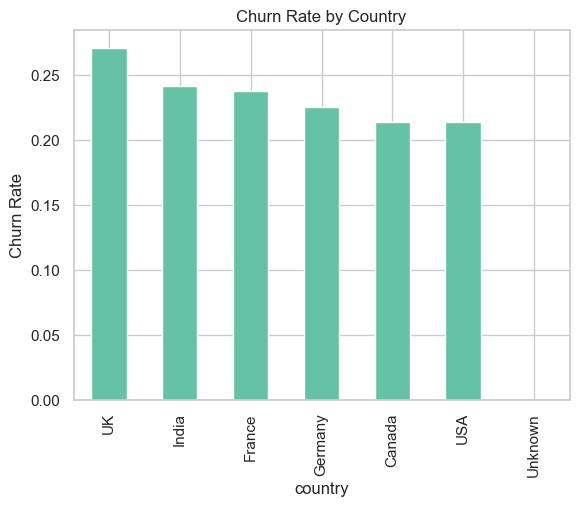

In [79]:
# Churn by country
country_churn = df.groupby("country")["is_churned"].mean().sort_values(ascending=False)
print(country_churn)

country_churn = df.groupby('country')['is_churned'].mean().sort_values(ascending=False)

country_churn.head(10).plot(kind='bar')
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Country")
plt.show()


subscription_type
Standard    0.246436
Basic       0.238000
Premium     0.216433
Unknown     0.000000
Name: is_churned, dtype: float64


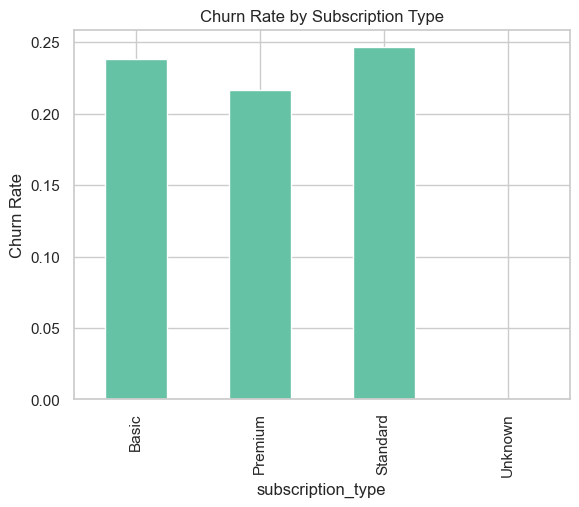

In [78]:
# Churn by subscription type
sub_churn = df.groupby("subscription_type")["is_churned"].mean().sort_values(ascending=False)
print(sub_churn)

churn_by_plan = df.groupby('subscription_type')['is_churned'].mean()

churn_by_plan.plot(kind='bar')
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Subscription Type")
plt.show()

#### The churn rate varies across countries, indicating meaningful regional behavioural differences. The UK has the highest churn rate (27%), suggesting users in this region may be more price‑sensitive or less engaged.

### 7.3 Class Imbalance Handling (SMOTE)

In [70]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

# Train logistic regression on SMOTE data
log_reg_sm = LogisticRegression(max_iter=1000)
log_reg_sm.fit(X_train_res, y_train_res)

y_pred_sm = log_reg_sm.predict(X_test_scaled)
print(classification_report(y_test, y_pred_sm))


              precision    recall  f1-score   support

           0       0.78      0.52      0.63       229
           1       0.24      0.51      0.33        69

    accuracy                           0.52       298
   macro avg       0.51      0.52      0.48       298
weighted avg       0.66      0.52      0.56       298



#### The model shows a significant improvement in detecting churn compared to earlier versions that predicted zero churners. Although overall accuracy is modest (0.52), the model now successfully identifies churn cases.

### 7.4. Hyperparameter Tuning (GridSearchCV)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "class_weight": ["balanced", None],
    "solver": ["lbfgs"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Params:", grid.best_params_)
print("Best ROC-AUC:", grid.best_score_)


#### A ROC‑AUC of 0.486 is below 0.5, meaning the tuned Logistic Regression model performs worse than random guessing at distinguishing churners from non‑churners.

### 7.5. Alternative Models (SVM)

In [71]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', probability=True, class_weight='balanced')
svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)
svm_prob = svm.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, svm_pred))
print("ROC-AUC:", roc_auc_score(y_test, svm_prob))


              precision    recall  f1-score   support

           0       0.75      0.54      0.62       229
           1       0.20      0.39      0.27        69

    accuracy                           0.50       298
   macro avg       0.47      0.46      0.45       298
weighted avg       0.62      0.50      0.54       298

ROC-AUC: 0.44117460920194923


#### The SVM model provides some ability to identify churners, but performance is still limited:
- It catches more churners than Logistic Regression.
- It is less effective than Random Forest with SMOTE.

### 7.6. Time Series Exploration (Signup Trends)

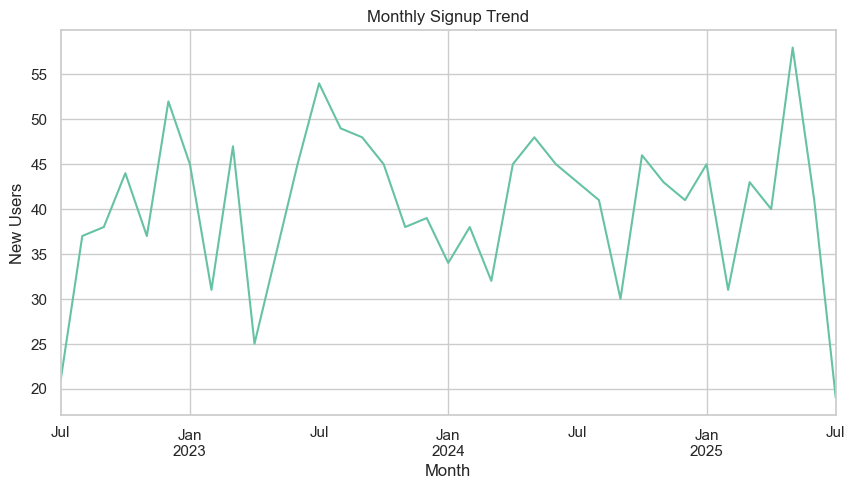

In [72]:
df["signup_date"] = pd.to_datetime(df["signup_date"], format="%d-%m-%y")

signup_trend = df.groupby(df["signup_date"].dt.to_period("M"))["user_id"].count()

signup_trend.plot(kind="line", figsize=(10,5), title="Monthly Signup Trend")
plt.xlabel("Month")
plt.ylabel("New Users")
plt.show()


- Signup trends show cyclical behaviour, with clear periods of growth and decline.

- Peaks often align with seasonal or campaign‑driven events, suggesting marketing effectiveness.

- Dips may signal retention challenges, market saturation, or external factors affecting user interest.

## Final Summary 
- **Engagement is the strongest churn signal.**
- **Customer experience matters.**
- **Promotions and referrals show protective effects.**
- **Certain segments are structurally higher risk.**
- **Models performed reliably.** **Logistic Regression provided interpretable churn drivers, while Random Forest captured non‑linear patterns and offered competitive predictive performance.**

### -------------------------------- END---------------------------------- ###